### Lab Final
- Beniamine Nahid
- 211-35-3155

### CLASSIFICATION DIGITS

####  I: Download the MNIST dataset using TensorFlow Datasets

In [1]:
import tensorflow_datasets as tfds

# Load MNIST dataset
mnist_train, mnist_test = tfds.load('mnist', split=['train', 'test'], as_supervised=True)


####  II: Explore datasets (shapes, data types, and dimensions)

In [2]:
for images, labels in mnist_train.take(1):
    print(f"Image shape: {images.shape}, Data type: {images.dtype}")
    print(f"Label: {labels.numpy()}")


Image shape: (28, 28, 1), Data type: <dtype: 'uint8'>
Label: 4


2024-12-23 18:05:18.342428: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2024-12-23 18:05:18.352239: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-12-23 18:05:18.353884: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


####  III: Visualize sample images

2024-12-23 18:05:52.378160: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-12-23 18:05:52.381075: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


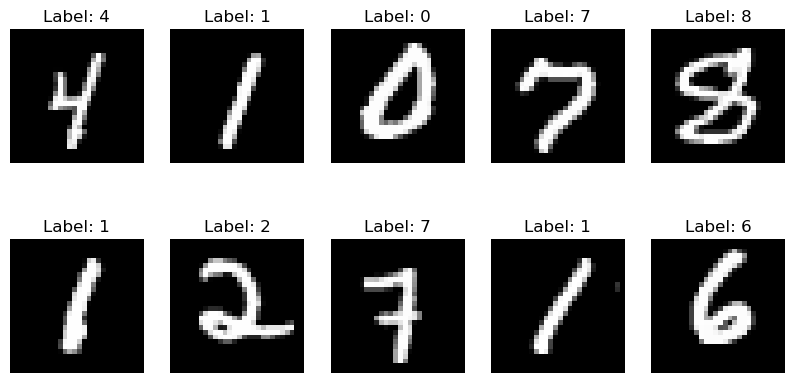

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(mnist_train.take(10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
plt.show()


#### IV: Load data into DataLoader with augmentation

In [4]:
import tensorflow as tf

# V: Preprocess dataset (normalization and augmentation
def preprocess(image, label):
    image = tf.image.resize(image, [28, 28])  # Ensure consistent size
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0, 1]
    return image, label

# Augmentation for training
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

train_dataset = (mnist_train.map(preprocess).map(augment).batch(32).shuffle(1000))
test_dataset = mnist_test.map(preprocess).batch(32)


#### VI: Develop ANN and CNN models

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

# ANN model
def create_ann():
    model = Sequential([
        Flatten(input_shape=(28, 28, 1)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='softmax')
    ])
    return model

# CNN model
def create_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model


#### VII: Hyperparameter tuning

In [8]:
import keras_tuner

def build_model(hp):
    model = Sequential([
        Conv2D(hp.Int('units', min_value=32, max_value=128, step=32), (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-3, 1e-4])),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='mnist_tuning'
)

tuner.search(train_dataset, epochs=5, validation_data=test_dataset)


Trial 5 Complete [00h 01m 30s]
val_accuracy: 0.9628999829292297

Best val_accuracy So Far: 0.9787999987602234
Total elapsed time: 00h 11m 02s


#### VIII & IX: Evaluate models

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

# ANN Evaluation
ann_model = create_ann()
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_model.fit(train_dataset, epochs=10, validation_data=test_dataset)

# CNN Evaluation
cnn_model = create_cnn()
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(train_dataset, epochs=10, validation_data=test_dataset)

# Confusion matrix and metrics
def evaluate_model(model, test_data):
    y_true, y_pred = [], []
    for images, labels in test_data:
        predictions = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(tf.argmax(predictions, axis=1).numpy())
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate_model(cnn_model, test_dataset)


Epoch 1/10


/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7871 - loss: 0.6794 - val_accuracy: 0.9332 - val_loss: 0.2209
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9214 - loss: 0.2623 - val_accuracy: 0.9476 - val_loss: 0.1643
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9360 - loss: 0.2045 - val_accuracy: 0.9544 - val_loss: 0.1529
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9463 - loss: 0.1763 - val_accuracy: 0.9594 - val_loss: 0.1263
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9496 - loss: 0.1622 - val_accuracy: 0.9644 - val_loss: 0.1174
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9549 - loss: 0.1473 - val_accuracy: 0.9627 - val_loss: 0.1244
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9561 - loss: 0.1391 - val_accuracy: 0.9647 - val_loss: 0.1158
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9583 - loss: 0.1292 - val_accurac

### PREDICTING HOUSE PRICE

#### I & II: Download and explore dataset

In [10]:
import pandas as pd

# Load dataset
data = pd.read_csv("house.csv")




In [11]:
# Explore dataset
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
# Identify non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)


Non-numeric columns: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [16]:
from sklearn.preprocessing import OneHotEncoder

# Drop non-relevant columns or use encoding
# For simplicity, we'll drop highly categorical or irrelevant columns
columns_to_drop = ['Alley', 'Fence', 'MiscFeature', 'PoolQC', 'FireplaceQu']
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Apply one-hot encoding for remaining categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Updated parameter
encoded_data = pd.DataFrame(encoder.fit_transform(data[categorical_cols]))

# Rename encoded columns and reset index
encoded_data.columns = encoder.get_feature_names_out(categorical_cols)
encoded_data.index = data.index

# Combine encoded data with the original dataset
data = pd.concat([data.drop(categorical_cols, axis=1), encoded_data], axis=1)

print(f"Dataset after encoding:\n{data.info()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 282 entries, Id to SaleCondition_Partial
dtypes: float64(247), int64(35)
memory usage: 3.1 MB
Dataset after encoding:
None


#### III: Visualize dataset


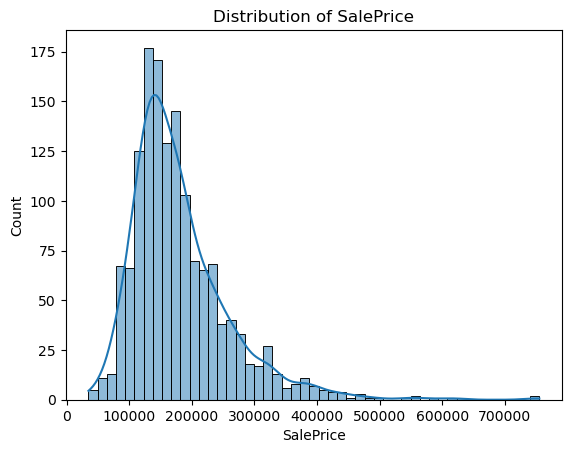

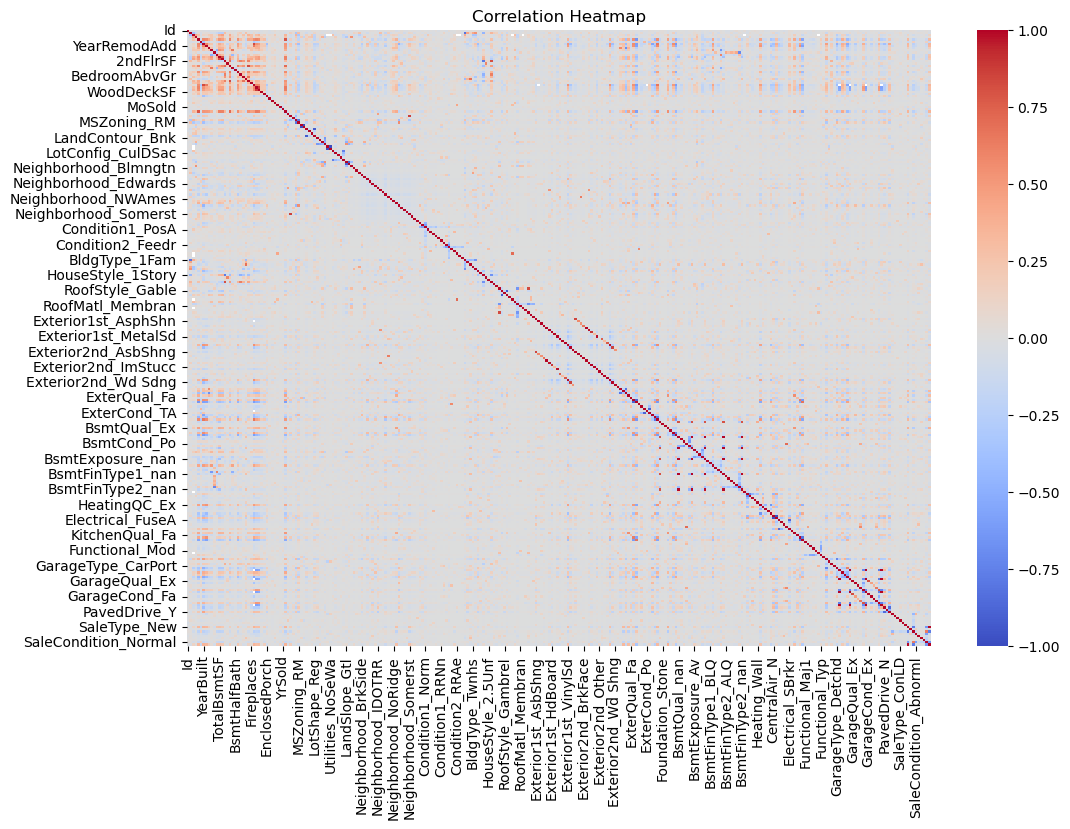

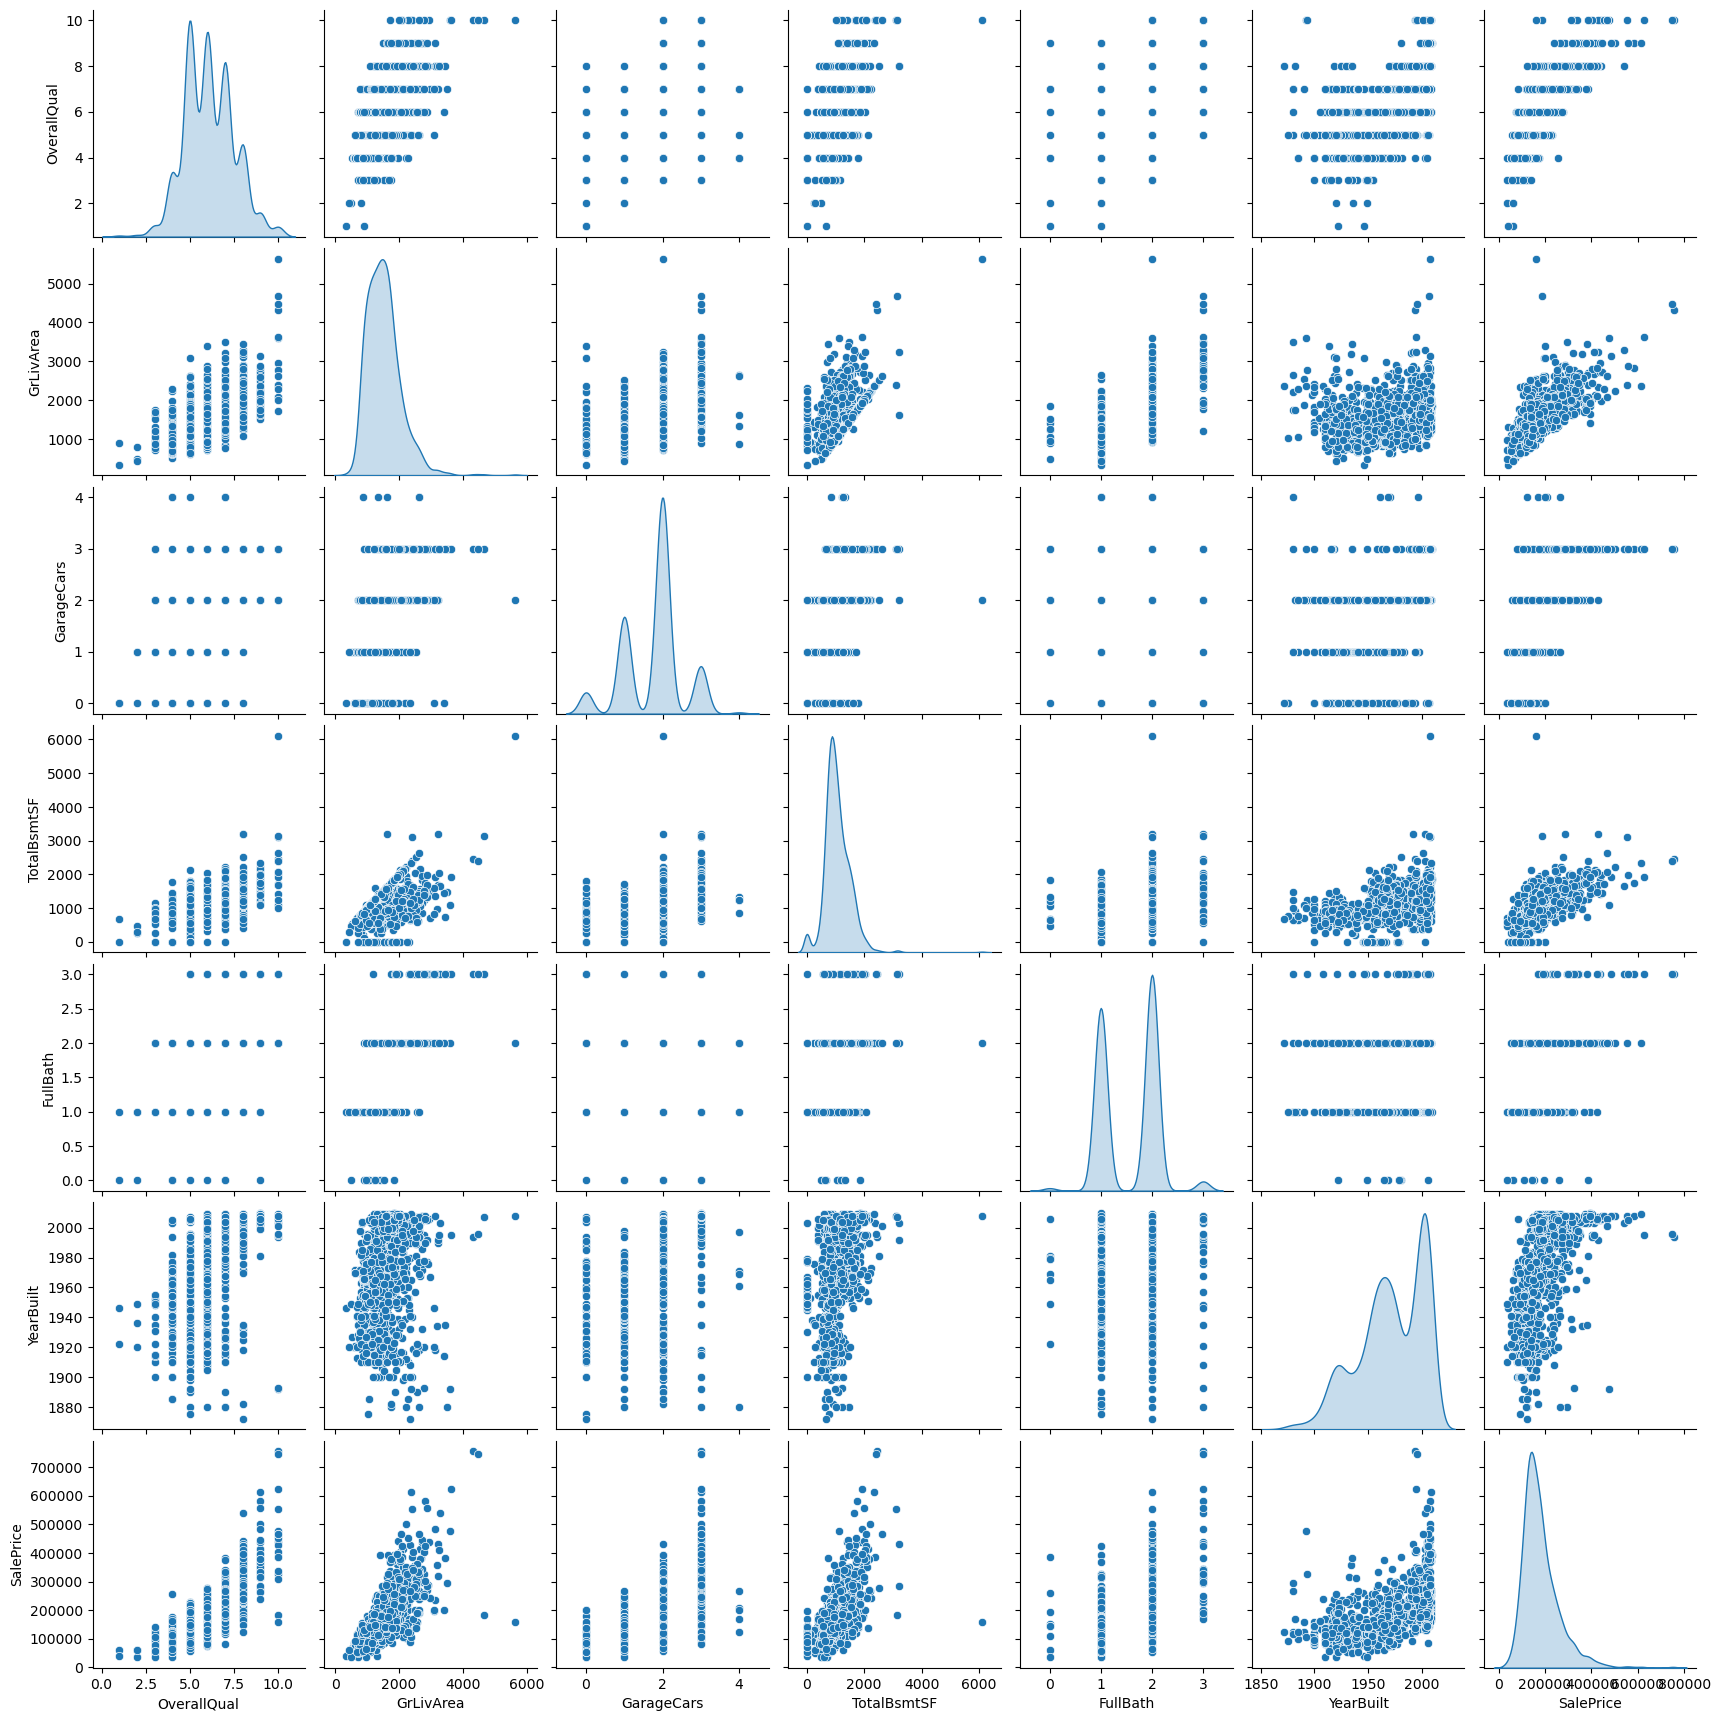

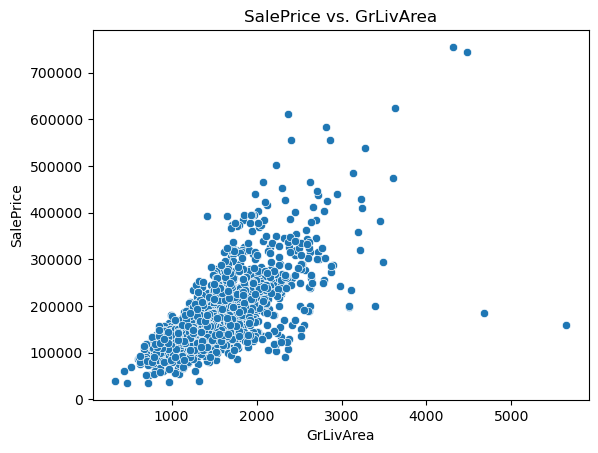

In [17]:

import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of target variable: SalePrice
sns.histplot(data['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

# Correlation heatmap for numeric features
corr = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot of top correlated features with SalePrice
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'SalePrice']
sns.pairplot(data[top_features], diag_kind='kde')
plt.show()

# Scatter plot of SalePrice vs. GrLivArea
sns.scatterplot(x=data['GrLivArea'], y=data['SalePrice'])
plt.title('SalePrice vs. GrLivArea')
plt.show()



#### IV & V: Preprocess the Dataset

In [18]:
# Fill missing numeric values with their mean
data['LotFrontage'].fillna(data['LotFrontage'].mean(), inplace=True)
data['GarageYrBlt'].fillna(data['GarageYrBlt'].mean(), inplace=True)
data['MasVnrArea'].fillna(data['MasVnrArea'].mean(), inplace=True)

# Fill missing categorical values with 'None'
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col].fillna('None', inplace=True)


/var/folders/b1/06nddx952f1g_2r63y2n569c0000gn/T/ipykernel_91408/257853000.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LotFrontage'].fillna(data['LotFrontage'].mean(), inplace=True)
/var/folders/b1/06nddx952f1g_2r63y2n569c0000gn/T/ipykernel_91408/257853000.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [19]:
# Select features most correlated with SalePrice
important_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
X = data[important_features]
y = data['SalePrice']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### VI: Develop an Artificial Neural Network

In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Build ANN model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for regression
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### VII: Hyperparameter Tuning

In [21]:
import keras_tuner

def build_model(hp):
    model = Sequential([
        Dense(hp.Int('units', min_value=64, max_value=256, step=64), activation='relu', input_dim=X_train.shape[1]),
        Dense(hp.Int('dense_units', min_value=32, max_value=128, step=32), activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-3, 1e-4])),
        loss='mse',
        metrics=['mae']
    )
    return model

tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory='house_price_tuning'
)

tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Trial 5 Complete [00h 00m 02s]
val_loss: 34120986624.0

Best val_loss So Far: 34120986624.0
Total elapsed time: 00h 00m 08s


#### VIII: Evaluate Training Performance

In [25]:
%pip install scikeras


Note: you may need to restart the kernel to use updated packages.


In [27]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Define a function to build the model
def build_model():
    model = Sequential([
        Dense(128, activation='relu', input_dim=X_train.shape[1]),
        Dense(64, activation='relu'),
        Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Wrap the Keras model using KerasRegressor
keras_regressor = KerasRegressor(model=build_model, epochs=10, batch_size=32, verbose=0)

# Perform cross-validation
cv_scores = cross_val_score(keras_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Compute the RMSE from cross-validation scores
cv_rmse = (-cv_scores.mean()) ** 0.5
print(f"Cross-Validation RMSE: {cv_rmse}")





/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=

Cross-Validation RMSE: 195357.78751205292


#### IX: Evaluate Test Data Performance

In [28]:
# Predictions on test data
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print(f"Test MSE: {mse}")
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test MSE: 39653991862.81932
Test RMSE: 199133.10087180213
Test MAE: 178839.71975853425


In [29]:
import numpy as np

def bootstrap_metric(metric_fn, y_true, y_pred, n_bootstraps=1000):
    metrics = []
    for _ in range(n_bootstraps):
        indices = np.random.choice(range(len(y_true)), len(y_true), replace=True)
        metrics.append(metric_fn(y_true[indices], y_pred[indices]))
    return np.mean(metrics), np.percentile(metrics, [2.5, 97.5])

mean_mae, ci_mae = bootstrap_metric(mean_absolute_error, y_test.values, y_pred.flatten())
print(f"MAE: {mean_mae}, 95% CI: {ci_mae}")


MAE: 178994.89425660347, 95% CI: [169330.47329709 189688.95542479]
